# Step 2 — Building the External Predictor Dataset

## Purpose

This notebook collects **external macroeconomic and financial variables**
that professional forecasters would have had access to when they made their
ECB SPF predictions.

The idea is simple: when a forecaster sits down in January 2020 to predict
inflation one year ahead, they don't just use gut feeling. They look at:

- What is the ECB doing with interest rates?
- What is the current inflation reading?
- How is the economy performing (GDP, unemployment)?
- What are oil prices doing?
- How are financial markets behaving?

If forecast errors are **systematic** — for example, if forecasters
consistently underpredict inflation when oil prices spike — then a neural
network might learn these patterns and correct the forecasts.

This notebook downloads ~20 external variables from four free data sources,
aligns them to the quarterly SPF survey rounds, and applies proper
**information timing** (we only use data that was actually available when
forecasters made their predictions).

## Data sources

| Source | What we get | API key needed? |
|---|---|---|
| **Yahoo Finance** | Stock returns, VIX, oil prices | No |
| **ECB Statistical Data Warehouse** | ECB rates, Euribor, bond yields, EUR/USD, M3 | No |
| **Eurostat** | HICP inflation, GDP, unemployment, industrial production, sentiment | No |
| **FRED** (Federal Reserve) | US CPI, US Fed Funds rate *(optional)* | Yes (free) |


---
## Variable selection rationale

We select variables across six categories. Each variable has a clear
theoretical reason for why it might help predict forecast errors.

### 1. Financial markets
| Variable | Why it matters |
|---|---|
| **Euro Stoxx 50 return** | Stock returns reflect growth expectations. A market rally might signal that growth will be stronger than forecasters expect. |
| **S&P 500 return** | The US market is a global growth barometer. US leads Europe by ~1–2 quarters. |
| **VIX (implied volatility)** | Measures market uncertainty. High VIX → larger forecast errors because the economy is harder to predict. |
| **Brent crude oil price** | Oil prices directly affect inflation through energy costs. Oil shocks cause systematic forecast errors. |

### 2. Monetary policy & interest rates
| Variable | Why it matters |
|---|---|
| **ECB main refinancing rate** | The key policy rate. Rate changes affect both inflation and GDP with a lag (12–18 months). |
| **3-month Euribor** | Reflects the market's expectation of near-term monetary policy. |
| **Euro area 10-year bond yield** | Long-term yields embed market expectations of future growth and inflation. |
| **Yield curve slope (10y − 3m)** | A classic recession signal. An inverted yield curve predicts recessions, which means growth forecasters are likely too optimistic. |

### 3. Exchange rates
| Variable | Why it matters |
|---|---|
| **EUR/USD exchange rate** | A weak euro makes imports more expensive, pushing inflation above forecasts. Also reflects relative monetary policy stance. |

### 4. Money & credit
| Variable | Why it matters |
|---|---|
| **M3 money supply growth** | Monetarist theory: money growth is a leading indicator of inflation. More money chasing the same goods → higher prices. |

### 5. Real economy (euro area)
| Variable | Why it matters |
|---|---|
| **HICP inflation (realized, lagged)** | Recent inflation is the strongest predictor of future inflation (persistence). Forecasters might underreact to recent changes. |
| **Core HICP (excl. energy & food)** | The underlying inflation trend, less volatile than headline HICP. |
| **Real GDP growth** | Recent growth helps predict growth forecast errors. Also affects inflation via the Phillips curve. |
| **Unemployment rate** | Low unemployment → wage pressure → inflation surprises. Also directly relevant for growth forecasts. |
| **Industrial production growth** | A coincident indicator of real activity. Moves before GDP is officially published. |

### 6. Sentiment & surveys
| Variable | Why it matters |
|---|---|
| **Economic Sentiment Indicator (ESI)** | A composite forward-looking survey. High ESI → economy doing better than expected. |
| **Consumer confidence** | Predicts household consumption, the largest GDP component. |

### 7. US economy (optional — needs FRED API key)
| Variable | Why it matters |
|---|---|
| **US CPI inflation** | Global inflation trends affect the euro area through trade and commodity markets. |
| **US Federal Funds rate** | Global monetary conditions. Fed policy affects capital flows and EUR/USD. |

**Total: ~20 variables** — enough to capture the key information channels
without overfitting.


---
## 1 — Imports and setup

We first install the packages we need. All data sources except FRED are
**completely free and keyless** — no registration required.


In [1]:
# Install required packages (run once)
# The --break-system-packages flag is needed on macOS with Homebrew Python.
# On other systems you can remove it.
import os
import subprocess
import sys

# Keep package/font caches inside the project so the notebook runs cleanly
# in sandboxed or university-lab environments where the home directory may
# not be writable.
CACHE_DIR = os.path.join(os.getcwd(), ".cache")
os.environ.setdefault("XDG_CACHE_HOME", CACHE_DIR)
os.environ.setdefault("MPLCONFIGDIR", os.path.join(CACHE_DIR, "matplotlib"))
os.makedirs(os.environ["MPLCONFIGDIR"], exist_ok=True)

packages = ["requests", "yfinance", "matplotlib", "seaborn", "fredapi"]
for pkg in packages:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", "-q",
             "--break-system-packages", "--user", pkg]
        )
        print(f"Installed {pkg}")

print("All packages ready.")


All packages ready.


In [2]:
import os
import warnings
from io import StringIO

import numpy as np
import pandas as pd
import requests
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 25)
pd.set_option("display.width", 140)

print(f"pandas   {pd.__version__}")
print(f"numpy    {np.__version__}")
print(f"yfinance {yf.__version__}")


pandas   3.0.2
numpy    2.4.4
yfinance 1.3.0


---
## 2 — Survey-round timeline and information timing

### When do forecasters make their predictions?

The ECB SPF survey is conducted four times a year. The **survey dates**
roughly align with the start of each quarter:

| Survey round | Conducted around | Forecasters have data through... |
|---|---|---|
| Q1 (e.g. 2020Q1) | Mid-January | December of previous year |
| Q2 (e.g. 2020Q2) | Mid-April | March |
| Q3 (e.g. 2020Q3) | Mid-July | June |
| Q4 (e.g. 2020Q4) | Mid-October | September |

### The information-timing constraint

This is **critical**: we must only use predictor values that were actually
available to forecasters when they made their predictions. If we accidentally
use data from the future (data that hadn't been published yet), we would
get artificially good results — a problem called **look-ahead bias**.

Different variables have different **publication lags**:
- **Financial market data** (stocks, exchange rates): available in real-time
  → we can use the previous month's data
- **HICP inflation**: published ~15 days after month end
  → we use data with a ~1 month lag
- **GDP**: flash estimate published ~30 days after quarter end
  → we use data with a ~2 month lag (1 quarter for quarterly data)
- **Unemployment, industrial production**: published ~30–45 days after month end
  → we use data with a ~2 month lag

### Our approach

For simplicity, we adopt a **uniform conservative rule**:

> For each survey round, we use predictor data from the **end of the
> previous quarter**.

This means:
- For survey round **2020Q1** (January), we use data available as of
  **Q4 2019** (October–December 2019).

This is slightly conservative (some data might have been available a bit
later), but it guarantees we never have look-ahead bias.


In [3]:
# Create the timeline of all survey rounds

# Load the actual survey rounds from step 1
spf_wide = pd.read_csv(os.path.join("Data", "spf_clean_wide.csv"))
valid_rounds = sorted(spf_wide["survey_round"].unique())
print(f"Survey rounds in SPF data: {valid_rounds[0]} to {valid_rounds[-1]} ({len(valid_rounds)} rounds)")

# Build the timeline dataframe
timeline = pd.DataFrame({"survey_round": valid_rounds})
timeline["survey_year"] = timeline["survey_round"].str[:4].astype(int)
timeline["survey_quarter"] = timeline["survey_round"].str[-1].astype(int)

# Helper: given a "YYYYQn" string, return the NEXT quarter
def next_quarter(qstr):
    y = int(qstr[:4])
    q = int(qstr[-1])
    q += 1
    if q > 4:
        q = 1
        y += 1
    return f"{y}Q{q}"

print(f"\nTimeline: {len(timeline)} survey rounds")
timeline.head(8)


Survey rounds in SPF data: 1999Q1 to 2026Q2 (110 rounds)

Timeline: 110 survey rounds


,survey_round,survey_year,survey_quarter
0,1999Q1,1999,1
1,1999Q2,1999,2
2,1999Q3,1999,3
3,1999Q4,1999,4
4,2000Q1,2000,1
5,2000Q2,2000,2
6,2000Q3,2000,3
7,2000Q4,2000,4


---
## 3 — Financial market data (Yahoo Finance)

We download four daily series from Yahoo Finance and convert them to
quarterly frequency. Yahoo Finance is free and doesn't require any API key.

| Ticker | Variable | Description |
|---|---|---|
| `^STOXX50E` | Euro Stoxx 50 | Main European blue-chip stock index (50 largest eurozone companies) |
| `^GSPC` | S&P 500 | Main US stock market index (500 largest US companies) |
| `^VIX` | VIX | CBOE Volatility Index — measures expected market volatility over next 30 days |
| `BZ=F` | Brent Crude | Brent crude oil futures price in USD per barrel |

For stock indices, we compute **quarterly returns** (percentage change over
the quarter) because the *change* in stock prices is more informative for
forecast errors than the *level*.

For oil prices, we keep the **quarterly average level** (because the level
of oil prices matters for inflation) and also the **quarterly change**.

For VIX, we keep the **quarterly average level** (higher VIX = more uncertainty).


In [4]:
# Download daily data from Yahoo Finance
# We start from 1998 to have a full Q4-1998 for computing Q1-1999 features

tickers = {
    "^STOXX50E": "eurostoxx50",
    "^GSPC":     "sp500",
    "^VIX":      "vix",
    "BZ=F":      "brent_oil",
}

print("Downloading from Yahoo Finance...")
yf_data = {}

for ticker, name in tickers.items():
    try:
        df = yf.download(ticker, start="1998-01-01", end="2026-07-01",
                         progress=False, auto_adjust=True)
        if len(df) == 0:
            print(f"  WARNING: {name} ({ticker}) — no data returned")
            continue
        # yfinance returns MultiIndex columns when downloading single ticker
        close = df["Close"]
        if isinstance(close, pd.DataFrame):
            close = close.iloc[:, 0]
        yf_data[name] = close.rename(name)
        print(f"  {name:15s} ({ticker:10s}): {len(df):,} daily observations, "
              f"{df.index.min().date()} to {df.index.max().date()}")
    except Exception as e:
        print(f"  ERROR downloading {name} ({ticker}): {e}")

# Combine into a single DataFrame
yf_daily = pd.DataFrame(yf_data)
print(f"\nCombined daily dataset: {yf_daily.shape[0]:,} rows × {yf_daily.shape[1]} columns")
print(f"Date range: {yf_daily.index.min().date()} to {yf_daily.index.max().date()}")
yf_daily.tail()


  eurostoxx50     (^STOXX50E ): 4,785 daily observations, 2007-03-30 to 2026-05-05


  sp500           (^GSPC     ): 7,128 daily observations, 1998-01-02 to 2026-05-05


  vix             (^VIX      ): 7,128 daily observations, 1998-01-02 to 2026-05-05


  brent_oil       (BZ=F      ): 4,670 daily observations, 2007-07-30 to 2026-05-05

Combined daily dataset: 7,238 rows × 4 columns
Date range: 1998-01-02 to 2026-05-05


,eurostoxx50,sp500,vix,brent_oil
Date,,,,
2026-04-29,5816.479980,7135.950195,18.809999,118.029999
2026-04-30,5881.509766,7209.009766,16.889999,114.010002
2026-05-01,NaN,7230.120117,16.990000,108.169998
2026-05-04,5763.609863,7200.750000,18.290001,114.440002
2026-05-05,5838.589844,7253.200195,17.370001,111.160004


In [5]:
# Convert daily data to quarterly frequency
# For each quarter, we compute:
#   - Average level (for VIX and oil)
#   - End-of-quarter level (for computing returns)
#   - Quarterly return = (end_of_quarter / end_of_previous_quarter) - 1

yf_quarterly_avg = yf_daily.resample("QE").mean()
yf_quarterly_end = yf_daily.resample("QE").last()

# Compute quarterly returns for stock indices
stock_cols = [c for c in ["eurostoxx50", "sp500"] if c in yf_quarterly_end.columns]
stock_returns = yf_quarterly_end[stock_cols].pct_change() * 100
stock_returns.columns = [f"{c}_return" for c in stock_cols]

# Compute oil price quarterly change (%)
oil_change = pd.DataFrame()
if "brent_oil" in yf_quarterly_end.columns:
    oil_change["oil_price_change_pct"] = yf_quarterly_end["brent_oil"].pct_change() * 100

# Build the quarterly financial features
yf_features = pd.DataFrame(index=yf_quarterly_avg.index)
for col in stock_returns.columns:
    yf_features[col] = stock_returns[col]
if "vix" in yf_quarterly_avg.columns:
    yf_features["vix_avg"] = yf_quarterly_avg["vix"]
if "brent_oil" in yf_quarterly_avg.columns:
    yf_features["oil_price_avg"] = yf_quarterly_avg["brent_oil"]
if "oil_price_change_pct" in oil_change.columns:
    yf_features["oil_price_change_pct"] = oil_change["oil_price_change_pct"]

# Map to survey_round format
# Financial data for quarter Q is available for the NEXT quarter's survey
# So Q4-2019 data (Oct-Dec 2019) → survey_round 2020Q1
yf_features["year"] = yf_features.index.year
yf_features["quarter"] = yf_features.index.quarter
yf_features["data_quarter"] = yf_features["year"].astype(str) + "Q" + yf_features["quarter"].astype(str)
yf_features["survey_round"] = yf_features["data_quarter"].apply(next_quarter)

# Keep only the columns we need
pred_cols = [c for c in yf_features.columns if c not in ["year", "quarter", "data_quarter"]]
yf_predictors = yf_features[pred_cols].copy()

print("Yahoo Finance quarterly predictors:")
print(f"  Shape: {yf_predictors.shape}")
print(f"  Survey rounds: {yf_predictors['survey_round'].iloc[0]} to {yf_predictors['survey_round'].iloc[-1]}")
yf_predictors.head(10)


Yahoo Finance quarterly predictors:
  Shape: (114, 6)
  Survey rounds: 1998Q2 to 2026Q3


,eurostoxx50_return,sp500_return,vix_avg,oil_price_avg,oil_price_change_pct,survey_round
Date,,,,,,
1998-03-31,NaN,NaN,21.324590,NaN,NaN,1998Q2
1998-06-30,NaN,2.912636,21.534286,NaN,NaN,1998Q3
1998-09-30,NaN,-10.303919,29.751719,NaN,NaN,1998Q4
1998-12-31,NaN,20.867048,29.537188,NaN,NaN,1999Q1
1999-03-31,NaN,4.648440,27.252787,NaN,NaN,1999Q2
1999-06-30,NaN,6.711908,24.395556,NaN,NaN,1999Q3
1999-09-30,NaN,-6.556374,23.320625,NaN,NaN,1999Q4
1999-12-31,NaN,14.542651,22.658281,NaN,NaN,2000Q1
2000-03-31,NaN,1.996254,23.150317,NaN,NaN,2000Q2


**Interpretation of the timing:** The row for `survey_round = 2020Q1`
contains financial market data from Q4-2019 (October–December 2019).
This is the most recent full quarter of market data that forecasters had
access to when filling out the Q1-2020 SPF survey in January 2020.


---
## 4 — ECB monetary policy & financial data (ECB Statistical Data Warehouse)

The ECB Statistical Data Warehouse (SDW) provides free access to ECB data
through a REST API. No API key is needed.

We download five series:

| Series | Description | ECB SDW Key |
|---|---|---|
| ECB MRO rate | Main refinancing operations rate — the key ECB policy rate | combine `FM/D.U2.EUR.4F.KR.MRR_FR.LEV` and `FM/D.U2.EUR.4F.KR.MRR_MBR.LEV` (daily, resampled to monthly) |
| 3-month Euribor | Interbank lending rate — reflects short-term monetary conditions | `FM/M.U2.EUR.RT.MM.EURIBOR3MD_.HSTA` |
| 10-year bond yield | German government bond yield — euro area benchmark | `IRS/M.DE.L.L40.CI.0000.EUR.N.Z` |
| EUR/USD exchange rate | Dollars per euro (monthly average) | `EXR/M.USD.EUR.SP00.A` |
| M3 money growth | Broad money annual growth rate | `BSI/M.U2.Y.V.M30.X.I.U2.2300.Z01.A` |

### How the ECB SDW API works

The ECB SDW uses the SDMX standard. Each series has a unique key made up
of dimension values separated by dots. The URL pattern is:

```
https://data-api.ecb.europa.eu/service/data/{dataflow}/{key}?format=csvdata&startPeriod=YYYY-MM
```

**Note:** ECB key interest rates are available at **daily** frequency.
The MRO rate has two historical regimes in the ECB API: fixed-rate tenders
and minimum-bid-rate tenders. We download both and combine them before
resampling to monthly end-of-month values.


In [6]:
# Helper function to download a series from the ECB SDW
def download_ecb_series(dataflow, key, name, start="1998-01", end="2026-06"):
    """
    Download a series from the ECB Statistical Data Warehouse.
    Returns a pd.Series with a DatetimeIndex, or None if download fails.
    """
    url = f"https://data-api.ecb.europa.eu/service/data/{dataflow}/{key}"
    params = {"format": "csvdata", "startPeriod": start, "endPeriod": end}

    try:
        resp = requests.get(url, params=params, timeout=60)
        resp.raise_for_status()

        df = pd.read_csv(StringIO(resp.text))

        if "TIME_PERIOD" not in df.columns or "OBS_VALUE" not in df.columns:
            print(f"  WARNING: {name} — unexpected columns: {df.columns.tolist()[:5]}")
            return None

        series = df[["TIME_PERIOD", "OBS_VALUE"]].copy()
        series["OBS_VALUE"] = pd.to_numeric(series["OBS_VALUE"], errors="coerce")
        series["date"] = pd.to_datetime(series["TIME_PERIOD"], format="mixed", dayfirst=False)
        series = series.dropna(subset=["OBS_VALUE"])
        series = series.set_index("date").sort_index()["OBS_VALUE"]
        series.name = name

        print(f"  {name:30s}: {len(series):5d} obs, {series.index.min().date()} to {series.index.max().date()}")
        return series

    except Exception as e:
        print(f"  ERROR downloading {name}: {e}")
        return None


print("Downloading from ECB Statistical Data Warehouse...")
print("(Official ECB REST API — no API key needed)\n")

ecb_series = {}

# 1. ECB Main Refinancing Rate — DAILY data.
#    The ECB API splits the MRO rate into historical tender regimes:
#    - fixed-rate tenders: 1999 to mid-2000, and again from late 2008 onward
#    - minimum-bid-rate tenders: mid-2000 to late 2008
#    We combine them below into one continuous `ecb_mro_rate` series.
ecb_series["ecb_mro_fixed_rate"] = download_ecb_series(
    "FM", "D.U2.EUR.4F.KR.MRR_FR.LEV", "ecb_mro_fixed_rate"
)
ecb_series["ecb_mro_min_bid_rate"] = download_ecb_series(
    "FM", "D.U2.EUR.4F.KR.MRR_MBR.LEV", "ecb_mro_min_bid_rate"
)

# 2. 3-month Euribor — monthly
ecb_series["euribor_3m"] = download_ecb_series(
    "FM", "M.U2.EUR.RT.MM.EURIBOR3MD_.HSTA", "euribor_3m"
)

# 3. 10-year government bond yield (Germany as euro area benchmark) — monthly
ecb_series["bond_yield_10y"] = download_ecb_series(
    "IRS", "M.DE.L.L40.CI.0000.EUR.N.Z", "bond_yield_10y"
)

# 4. EUR/USD exchange rate (monthly average)
ecb_series["eur_usd"] = download_ecb_series(
    "EXR", "M.USD.EUR.SP00.A", "eur_usd"
)

# 5. M3 money supply annual growth rate (already YoY %, not an index)
ecb_series["m3_yoy_growth"] = download_ecb_series(
    "BSI", "M.U2.Y.V.M30.X.I.U2.2300.Z01.A", "m3_yoy_growth"
)

n_ok = sum(1 for v in ecb_series.values() if v is not None)
print(f"\nSuccessfully downloaded {n_ok}/{len(ecb_series)} ECB series.")


(Official ECB REST API — no API key needed)



  ecb_mro_fixed_rate            :  6956 obs, 1999-01-01 to 2026-05-05


  ecb_mro_min_bid_rate          :  3031 obs, 2000-06-28 to 2008-10-14


  euribor_3m                    :   340 obs, 1998-01-01 to 2026-04-01


  bond_yield_10y                :   339 obs, 1998-01-01 to 2026-03-01


  eur_usd                       :   328 obs, 1999-01-01 to 2026-04-01
  m3_yoy_growth                 :   339 obs, 1998-01-01 to 2026-03-01

Successfully downloaded 6/6 ECB series.


In [7]:
# Process ECB series to quarterly frequency

# Step 1: Combine the two MRO tender-regime series into one continuous daily series.
mro_parts = {
    "fixed_rate": ecb_series.pop("ecb_mro_fixed_rate", None),
    "min_bid_rate": ecb_series.pop("ecb_mro_min_bid_rate", None),
}
mro_parts = {k: v for k, v in mro_parts.items() if v is not None}

if mro_parts:
    mro_daily = pd.DataFrame(mro_parts).sort_index()
    # For each date, use the fixed-rate tender value when present; otherwise
    # use the minimum-bid-rate tender value. The regimes barely overlap.
    ecb_series["ecb_mro_rate"] = (
        mro_daily.bfill(axis=1).iloc[:, 0]
        .resample("ME").last()
        .ffill()
    )
    print(
        "Combined and resampled MRO rate: "
        f"{len(ecb_series['ecb_mro_rate'])} monthly observations"
    )

# Step 2: Combine all monthly ECB series
ecb_monthly = pd.DataFrame({k: v for k, v in ecb_series.items() if v is not None})

if len(ecb_monthly.columns) > 0:
    print(f"ECB monthly data: {ecb_monthly.shape[0]} months × {ecb_monthly.shape[1]} series")

    # M3 is downloaded directly as an annual growth rate, so we do not
    # transform it again. A second pct_change would create impossible values.

    # Compute yield curve slope (10y bond yield minus 3m Euribor)
    if "bond_yield_10y" in ecb_monthly.columns and "euribor_3m" in ecb_monthly.columns:
        ecb_monthly["yield_curve_slope"] = ecb_monthly["bond_yield_10y"] - ecb_monthly["euribor_3m"]

    # Resample to quarterly (average over the quarter)
    ecb_quarterly = ecb_monthly.resample("QE").mean()

    # Map to survey rounds (1-quarter lag: Q4 data → Q1 survey)
    ecb_quarterly["year"] = ecb_quarterly.index.year
    ecb_quarterly["quarter"] = ecb_quarterly.index.quarter
    ecb_quarterly["data_quarter"] = ecb_quarterly["year"].astype(str) + "Q" + ecb_quarterly["quarter"].astype(str)
    ecb_quarterly["survey_round"] = ecb_quarterly["data_quarter"].apply(next_quarter)

    ecb_cols = [c for c in ecb_quarterly.columns if c not in ["year", "quarter", "data_quarter"]]
    ecb_predictors = ecb_quarterly[ecb_cols].copy()

    print(f"\nECB quarterly predictors: {ecb_predictors.shape}")
    ecb_predictors.head(8)
else:
    ecb_predictors = pd.DataFrame(columns=["survey_round"])
    print("WARNING: No ECB data downloaded.")


Combined and resampled MRO rate: 329 monthly observations
ECB monthly data: 669 months × 5 series

ECB quarterly predictors: (114, 7)


---
## 5 — Euro area macro data (Eurostat)

Eurostat is the statistical office of the European Union. It provides free
access to all official EU/euro area statistics through a REST API.

We download five key macro variables using the **Eurostat JSON Statistics API**.
This API uses query parameters to filter data, making it straightforward to use.

| Dataset | Variable | Description |
|---|---|---|
| `prc_hicp_manr` | HICP inflation | Year-on-year change in the Harmonised Index of Consumer Prices (monthly) |
| `prc_hicp_manr` | Core HICP | HICP excluding energy, food, alcohol & tobacco — the underlying inflation trend |
| `namq_10_gdp` | Real GDP growth | Quarter-on-quarter growth of real GDP (chain-linked volumes, seasonally adjusted) |
| `une_rt_m` | Unemployment rate | Harmonised unemployment rate (monthly, seasonally adjusted) |
| `sts_inpr_m` | Industrial production | Industrial production index (we compute year-on-year change) |

### How the Eurostat JSON Statistics API works

The URL pattern is:
```
https://ec.europa.eu/eurostat/api/dissemination/statistics/1.0/data/{dataset}?param1=value1&param2=value2
```

The parameters filter by dimension (e.g., `geo=EA20` for euro area,
`freq=M` for monthly). The response is JSON with a specific structure
where values are indexed by position.


In [8]:
def download_eurostat_json(dataset, params, name):
    """
    Download a series from the Eurostat JSON Statistics API.
    Returns a pd.Series with DatetimeIndex, or None if download fails.
    """
    base_url = f"https://ec.europa.eu/eurostat/api/dissemination/statistics/1.0/data/{dataset}"
    params = {**params, "lang": "en"}

    try:
        resp = requests.get(base_url, params=params, timeout=60)
        resp.raise_for_status()
        data = resp.json()

        values = data.get("value", {})
        if not values:
            print(f"  WARNING: {name} — no data returned (empty values)")
            return None

        # Parse the time dimension to map flat JSON-stat value positions to dates.
        # Eurostat returns values in a flattened multidimensional array, so the
        # time position must be decoded using the dimension sizes and order.
        dims = data["dimension"]
        dim_ids = data["id"]   # ordered list of dimension names
        dim_sizes = data["size"]  # size of each dimension

        # Find the time dimension
        time_dim_name = [d for d in dim_ids if "time" in d.lower()][0]
        time_idx = dim_ids.index(time_dim_name)
        time_category_index = dims[time_dim_name]["category"]["index"]
        time_labels_by_pos = {int(pos): label for label, pos in time_category_index.items()}

        # Row-major strides: for dimension i, divide by the product of sizes
        # of dimensions to its right, then take modulo size_i.
        strides = []
        for i in range(len(dim_sizes)):
            stride = int(np.prod(dim_sizes[i + 1:])) if i + 1 < len(dim_sizes) else 1
            strides.append(stride)

        # Build the time series
        records = []
        for flat_idx_str, val in values.items():
            flat_idx = int(flat_idx_str)
            time_pos = (flat_idx // strides[time_idx]) % dim_sizes[time_idx]
            period = time_labels_by_pos.get(time_pos)
            if period is not None:
                records.append((period, val))

        if not records:
            print(f"  WARNING: {name} — could not parse values")
            return None

        df = pd.DataFrame(records, columns=["period", "value"])
        df["value"] = pd.to_numeric(df["value"], errors="coerce")
        df = df.groupby("period", as_index=False)["value"].mean()

        # Parse period: "2020-01" (monthly) or "2020-Q1" (quarterly)
        def parse_period(p):
            p = str(p)
            if "-Q" in p:
                y, q = p.split("-Q")
                m = (int(q) - 1) * 3 + 1
                return pd.Timestamp(int(y), m, 1)
            else:
                return pd.to_datetime(p, format="mixed")

        df["date"] = df["period"].apply(parse_period)
        series = df.set_index("date").sort_index()["value"]
        series.name = name

        print(f"  {name:30s}: {len(series):4d} obs, {series.index.min().date()} to {series.index.max().date()}")
        return series

    except Exception as e:
        print(f"  ERROR downloading {name}: {e}")
        return None


print("Downloading from Eurostat (JSON Statistics API)...")
print("(Official EU statistics — no API key needed)\n")

eurostat_series = {}

# 1. HICP inflation — year-on-year rate of change, all items, euro area 20
eurostat_series["hicp_inflation"] = download_eurostat_json(
    "prc_hicp_manr",
    {"geo": "EA20", "coicop": "CP00", "unit": "RCH_A", "freq": "M",
     "startPeriod": "1998-01", "endPeriod": "2026-06"},
    "hicp_inflation"
)

# 2. Core HICP — excluding energy, food, alcohol, tobacco
eurostat_series["core_hicp"] = download_eurostat_json(
    "prc_hicp_manr",
    {"geo": "EA20", "coicop": "TOT_X_NRG_FOOD", "unit": "RCH_A", "freq": "M",
     "startPeriod": "1998-01", "endPeriod": "2026-06"},
    "core_hicp"
)

# 3. Real GDP growth — quarter-on-quarter, chain-linked volumes, seasonally adjusted
eurostat_series["gdp_growth_qoq"] = download_eurostat_json(
    "namq_10_gdp",
    {"geo": "EA20", "na_item": "B1GQ", "s_adj": "SCA", "unit": "CLV_PCH_PRE", "freq": "Q",
     "startPeriod": "1998-Q1", "endPeriod": "2026-Q4"},
    "gdp_growth_qoq"
)

# 4. Unemployment rate — monthly, seasonally adjusted, total, euro area
#    Note: For this dataset the euro area geo code is "EA21" (not "EA20")
eurostat_series["unemployment_rate"] = download_eurostat_json(
    "une_rt_m",
    {"geo": "EA21", "age": "TOTAL", "sex": "T", "s_adj": "SA",
     "unit": "PC_ACT", "freq": "M",
     "startPeriod": "1998-01", "endPeriod": "2026-06"},
    "unemployment_rate"
)

# 5. Industrial production index — total industry, seasonally & calendar adjusted
#    We download the index level (I21 = index 2021=100) and compute YoY growth ourselves
eurostat_series["industrial_prod_idx"] = download_eurostat_json(
    "sts_inpr_m",
    {"geo": "EA20", "nace_r2": "B-D", "s_adj": "SCA", "unit": "I21", "freq": "M",
     "startPeriod": "1998-01", "endPeriod": "2026-06"},
    "industrial_prod_idx"
)

n_ok = sum(1 for v in eurostat_series.values() if v is not None)
print(f"\nSuccessfully downloaded {n_ok}/{len(eurostat_series)} Eurostat series.")


(Official EU statistics — no API key needed)



  hicp_inflation                :  301 obs, 2000-12-01 to 2025-12-01
  core_hicp                     :  289 obs, 2001-12-01 to 2025-12-01


  gdp_growth_qoq                :  113 obs, 1998-01-01 to 2026-01-01


  unemployment_rate             :  315 obs, 2000-01-01 to 2026-03-01
  industrial_prod_idx           :  338 obs, 1998-01-01 to 2026-02-01

Successfully downloaded 5/5 Eurostat series.


In [9]:
# Process Eurostat data to quarterly frequency aligned with survey rounds

# Compute industrial production YoY growth from the index
if eurostat_series.get("industrial_prod_idx") is not None:
    ip = eurostat_series["industrial_prod_idx"]
    ip_yoy = ip.pct_change(12) * 100  # 12-month % change
    ip_yoy.name = "industrial_prod_yoy"
    eurostat_series["industrial_prod_yoy"] = ip_yoy
    del eurostat_series["industrial_prod_idx"]  # we don't need the raw index

# Separate monthly and quarterly series
monthly_keys = [k for k, v in eurostat_series.items()
                if v is not None and k != "gdp_growth_qoq"]
quarterly_keys = [k for k, v in eurostat_series.items()
                  if v is not None and k == "gdp_growth_qoq"]

# --- Monthly → quarterly ---
if monthly_keys:
    eurostat_monthly = pd.DataFrame({k: eurostat_series[k] for k in monthly_keys})
    # Take the last month of each quarter (most up-to-date value)
    eurostat_monthly_q = eurostat_monthly.resample("QE").last()

    eurostat_monthly_q["year"] = eurostat_monthly_q.index.year
    eurostat_monthly_q["quarter"] = eurostat_monthly_q.index.quarter
    eurostat_monthly_q["data_quarter"] = (
        eurostat_monthly_q["year"].astype(str) + "Q" + eurostat_monthly_q["quarter"].astype(str)
    )
    # 1-quarter lag (macro data has publication delays)
    eurostat_monthly_q["survey_round"] = eurostat_monthly_q["data_quarter"].apply(next_quarter)
    euro_m_cols = [c for c in eurostat_monthly_q.columns if c not in ["year", "quarter", "data_quarter"]]
    eurostat_m_pred = eurostat_monthly_q[euro_m_cols].copy()
else:
    eurostat_m_pred = pd.DataFrame(columns=["survey_round"])

# --- Quarterly GDP ---
if quarterly_keys:
    gdp_df = pd.DataFrame({k: eurostat_series[k] for k in quarterly_keys})
    gdp_df["year"] = gdp_df.index.year
    gdp_df["quarter"] = gdp_df.index.quarter
    gdp_df["data_quarter"] = gdp_df["year"].astype(str) + "Q" + gdp_df["quarter"].astype(str)
    gdp_df["survey_round"] = gdp_df["data_quarter"].apply(next_quarter)
    gdp_pred = gdp_df[["survey_round", "gdp_growth_qoq"]].copy()
else:
    gdp_pred = pd.DataFrame(columns=["survey_round"])

# Merge monthly and quarterly eurostat predictors
eurostat_predictors = pd.merge(eurostat_m_pred, gdp_pred, on="survey_round", how="outer")

print("Eurostat quarterly predictors:")
print(f"  Shape: {eurostat_predictors.shape}")
if len(eurostat_predictors) > 0:
    cols = [c for c in eurostat_predictors.columns if c != "survey_round"]
    print(f"  Variables: {cols}")
eurostat_predictors.head(8)


Eurostat quarterly predictors:
  Shape: (113, 6)
  Variables: ['hicp_inflation', 'core_hicp', 'unemployment_rate', 'industrial_prod_yoy', 'gdp_growth_qoq']


,hicp_inflation,core_hicp,unemployment_rate,industrial_prod_yoy,survey_round,gdp_growth_qoq
0,NaN,NaN,NaN,NaN,1998Q2,0.7
1,NaN,NaN,NaN,NaN,1998Q3,0.4
2,NaN,NaN,NaN,NaN,1998Q4,0.5
3,NaN,NaN,NaN,NaN,1999Q1,0.3
4,NaN,NaN,NaN,-0.118624,1999Q2,1.0
5,NaN,NaN,NaN,1.065089,1999Q3,0.5
6,NaN,NaN,NaN,2.721893,1999Q4,1.3
7,NaN,NaN,NaN,5.143541,2000Q1,1.1


---
## 6 — Sentiment indicators (European Commission via Eurostat)

The European Commission publishes monthly business and consumer survey
indicators. These are **forward-looking** indicators based on surveys of
businesses and consumers, making them particularly useful for predicting
forecast errors.

| Variable | Description |
|---|---|
| **Economic Sentiment Indicator (ESI)** | A composite index (average = 100) based on five sector-specific confidence indicators: industrial, services, consumer, retail, and construction. Values above 100 indicate above-average confidence. |
| **Consumer confidence indicator** | How consumers feel about the economy, their financial situation, and their spending plans. Ranges from about −40 (very pessimistic) to +40 (very optimistic). |

These indicators have very short publication lags (~2 days after the
reference month), so they give forecasters near-real-time information
about economic sentiment.


In [10]:
# Download sentiment indicators from Eurostat
# Dataset: ei_bssi_m_r2 (Business and consumer surveys - monthly)
# Note: for this dataset, geo="EA20" works (not EA or EA21)

print("Downloading sentiment indicators from Eurostat...\n")

sentiment_series = {}

# 1. Economic Sentiment Indicator (ESI)
sentiment_series["esi"] = download_eurostat_json(
    "ei_bssi_m_r2",
    {"geo": "EA20", "s_adj": "SA", "indic": "BS-ESI-I", "freq": "M",
     "startPeriod": "1998-01", "endPeriod": "2026-06"},
    "esi"
)

# 2. Consumer Confidence Indicator
sentiment_series["consumer_confidence"] = download_eurostat_json(
    "ei_bssi_m_r2",
    {"geo": "EA20", "s_adj": "SA", "indic": "BS-CSMCI-BAL", "freq": "M",
     "startPeriod": "1998-01", "endPeriod": "2026-06"},
    "consumer_confidence"
)

n_ok = sum(1 for v in sentiment_series.values() if v is not None)
print(f"\nSuccessfully downloaded {n_ok}/{len(sentiment_series)} sentiment series.")


  esi                           :  336 obs, 1998-01-01 to 2025-12-01


  consumer_confidence           :  336 obs, 1998-01-01 to 2025-12-01

Successfully downloaded 2/2 sentiment series.


In [11]:
# Process sentiment indicators to quarterly frequency
valid_sentiment = {k: v for k, v in sentiment_series.items() if v is not None}

if valid_sentiment:
    sent_monthly = pd.DataFrame(valid_sentiment)
    sent_quarterly = sent_monthly.resample("QE").mean()  # quarterly average

    sent_quarterly["year"] = sent_quarterly.index.year
    sent_quarterly["quarter"] = sent_quarterly.index.quarter
    sent_quarterly["data_quarter"] = (
        sent_quarterly["year"].astype(str) + "Q" + sent_quarterly["quarter"].astype(str)
    )
    # 1-quarter lag (conservative, even though pub lag is very short)
    sent_quarterly["survey_round"] = sent_quarterly["data_quarter"].apply(next_quarter)

    sent_cols = [c for c in sent_quarterly.columns if c not in ["year", "quarter", "data_quarter"]]
    sentiment_predictors = sent_quarterly[sent_cols].copy()
    print(f"Sentiment quarterly predictors: {sentiment_predictors.shape}")
    sentiment_predictors.head()
else:
    sentiment_predictors = pd.DataFrame(columns=["survey_round"])
    print("WARNING: No sentiment data downloaded.")


Sentiment quarterly predictors: (112, 3)


---
## 7 — US macroeconomic data (FRED) — *optional*

The Federal Reserve Economic Data (FRED) database is one of the most
comprehensive free economic data sources. It requires a **free API key**
which you can get in 2 minutes at:

https://fred.stlouisfed.org/docs/api/api_key.html

We download two US variables:
- **US CPI inflation** (year-on-year) — global inflation trends
- **US Federal Funds rate** — the Fed's policy rate, affects global
  monetary conditions

If you don't have a FRED API key yet, this section will be skipped
gracefully and the notebook will continue without US data.


In [12]:
# ============================================================
# FRED API KEY — REPLACE WITH YOUR OWN KEY
# Get a free key at: https://fred.stlouisfed.org/docs/api/api_key.html
# ============================================================
FRED_API_KEY = "YOUR_FRED_API_KEY_HERE"  # ← paste your key here
# ============================================================

fred_predictors = pd.DataFrame(columns=["survey_round"])

if FRED_API_KEY == "YOUR_FRED_API_KEY_HERE":
    print("No FRED API key provided — skipping US data download.")
    print("To add US data, get a free key at: https://fred.stlouisfed.org/docs/api/api_key.html")
    print("Then paste it in the FRED_API_KEY variable above and re-run this cell.")
else:
    try:
        from fredapi import Fred
        fred = Fred(api_key=FRED_API_KEY)

        print("Downloading from FRED (Federal Reserve Economic Data)...\n")

        fred_series = {}

        # 1. US CPI — all items, year-on-year % change
        cpi = fred.get_series("CPIAUCSL", observation_start="1998-01-01")
        cpi_yoy = cpi.pct_change(12) * 100
        cpi_yoy.name = "us_cpi_yoy"
        fred_series["us_cpi_yoy"] = cpi_yoy
        print(f"  us_cpi_yoy           : {len(cpi_yoy)} obs")

        # 2. US Federal Funds Rate (effective)
        ffr = fred.get_series("FEDFUNDS", observation_start="1998-01-01")
        ffr.name = "us_fed_funds_rate"
        fred_series["us_fed_funds_rate"] = ffr
        print(f"  us_fed_funds_rate    : {len(ffr)} obs")

        # Combine and resample to quarterly
        fred_monthly = pd.DataFrame(fred_series)
        fred_quarterly = fred_monthly.resample("QE").mean()

        fred_quarterly["year"] = fred_quarterly.index.year
        fred_quarterly["quarter"] = fred_quarterly.index.quarter
        fred_quarterly["data_quarter"] = (
            fred_quarterly["year"].astype(str) + "Q" + fred_quarterly["quarter"].astype(str)
        )
        fred_quarterly["survey_round"] = fred_quarterly["data_quarter"].apply(next_quarter)

        fred_cols = [c for c in fred_quarterly.columns
                     if c not in ["year", "quarter", "data_quarter"]]
        fred_predictors = fred_quarterly[fred_cols].copy()
        print(f"\nFRED quarterly predictors: {fred_predictors.shape}")
        fred_predictors.head()

    except Exception as e:
        print(f"ERROR with FRED: {e}")
        print("Continuing without US data.")


No FRED API key provided — skipping US data download.
To add US data, get a free key at: https://fred.stlouisfed.org/docs/api/api_key.html
Then paste it in the FRED_API_KEY variable above and re-run this cell.


---
## 8 — Merge all predictors into one dataset

Now we combine all the quarterly predictors from different sources into a
single dataset, keyed by `survey_round`. Each row represents one survey
round and contains all the predictor variables that were available to
forecasters at that time.


In [13]:
# Start with the survey round timeline
predictors = timeline[["survey_round"]].copy()
print(f"Starting with {len(predictors)} survey rounds: "
      f"{predictors['survey_round'].iloc[0]} to {predictors['survey_round'].iloc[-1]}")

# Merge each source
sources = {
    "Yahoo Finance":    yf_predictors,
    "ECB SDW":          ecb_predictors,
    "Eurostat (macro)": eurostat_predictors,
    "Sentiment":        sentiment_predictors,
    "FRED (US)":        fred_predictors,
}

for source_name, source_df in sources.items():
    if len(source_df) == 0 or (len(source_df.columns) == 1 and "survey_round" in source_df.columns):
        print(f"  {source_name:20s}: SKIPPED (no data)")
        continue

    n_vars = len([c for c in source_df.columns if c != "survey_round"])
    predictors = pd.merge(predictors, source_df, on="survey_round", how="left")
    print(f"  {source_name:20s}: merged {n_vars} variables")

print(f"\nMerged predictor dataset: {predictors.shape[0]} rows × {predictors.shape[1]} columns")
print(f"\nAll columns:")
for col in predictors.columns:
    if col != "survey_round":
        print(f"  {col}")


Starting with 110 survey rounds: 1999Q1 to 2026Q2
  Yahoo Finance       : merged 5 variables
  ECB SDW             : merged 6 variables
  Eurostat (macro)    : merged 5 variables
  Sentiment           : merged 2 variables
  FRED (US)           : SKIPPED (no data)

Merged predictor dataset: 110 rows × 19 columns

All columns:
  eurostoxx50_return
  sp500_return
  vix_avg
  oil_price_avg
  oil_price_change_pct
  euribor_3m
  bond_yield_10y
  eur_usd
  m3_yoy_growth
  ecb_mro_rate
  yield_curve_slope
  hicp_inflation
  core_hicp
  unemployment_rate
  industrial_prod_yoy
  gdp_growth_qoq
  esi
  consumer_confidence


In [14]:
# Quick look at the merged dataset
predictors.head(10)


,survey_round,eurostoxx50_return,sp500_return,vix_avg,oil_price_avg,oil_price_change_pct,euribor_3m,bond_yield_10y,eur_usd,m3_yoy_growth,ecb_mro_rate,yield_curve_slope,hicp_inflation,core_hicp,unemployment_rate,industrial_prod_yoy,gdp_growth_qoq,esi,consumer_confidence
0,1999Q1,NaN,20.867048,29.537188,NaN,NaN,3.623333,4.013333,NaN,4.994669,NaN,0.390000,NaN,NaN,NaN,NaN,0.3,108.400000,-2.466667
1,1999Q2,NaN,4.648440,27.252787,NaN,NaN,3.090732,3.863333,1.123280,5.761870,3.000000,0.772601,NaN,NaN,NaN,-0.118624,1.0,105.166667,-2.866667
2,1999Q3,NaN,6.711908,24.395556,NaN,NaN,2.634030,4.073333,1.057002,5.563899,2.500000,1.439304,NaN,NaN,NaN,1.065089,0.5,103.966667,-4.933333
3,1999Q4,NaN,-6.556374,23.320625,NaN,NaN,2.699394,4.866667,1.048567,5.805109,2.500000,2.167273,NaN,NaN,NaN,2.721893,1.3,106.800000,-3.700000
4,2000Q1,NaN,14.542651,22.658281,NaN,NaN,3.429798,5.160000,1.038490,5.649546,2.833333,1.730202,NaN,NaN,NaN,5.143541,1.1,113.966667,-1.466667
5,2000Q2,NaN,1.996254,23.150317,NaN,NaN,3.542316,5.460000,0.987154,5.618413,3.250000,1.917684,NaN,NaN,9.4,5.581948,1.3,117.200000,-0.533333
6,2000Q3,NaN,-2.934777,24.923968,NaN,NaN,4.263017,5.263333,0.934032,5.271214,3.916667,1.000316,NaN,NaN,9.2,5.386417,0.9,117.066667,-1.133333
7,2000Q4,NaN,-1.243639,19.169048,NaN,NaN,4.737600,5.246667,0.905276,4.344492,4.333333,0.509066,NaN,NaN,9.1,5.069124,0.7,116.166667,-1.766667
8,2001Q1,NaN,-8.091136,26.016667,NaN,NaN,5.024128,5.083333,0.869620,3.962299,4.750000,0.059205,2.6,NaN,8.9,5.574516,0.5,115.100000,-1.900000
9,2001Q2,NaN,-12.114860,25.726452,NaN,NaN,4.745055,4.750000,0.923170,3.755976,4.750000,0.004945,2.3,NaN,8.7,3.487064,1.1,110.600000,-1.900000


---
## 9 — Compute derived features

Some useful predictors are not raw variables but **transformations** or
**combinations** of raw variables. These capture economic relationships
that a neural network might otherwise struggle to learn.

| Derived feature | Formula | Why |
|---|---|---|
| `yield_curve_slope` | 10y bond yield − 3m Euribor | Already computed in Section 4. Classic recession predictor. |
| `oil_price_log` | log(oil price) | Oil price effects on inflation are better captured in logs (% changes are more stable). |
| `eur_usd_change` | Quarterly change in EUR/USD | Currency depreciation pushes up import prices → inflation. |
| `real_interest_rate` | ECB MRO rate − HICP inflation | Measures how tight monetary policy actually is in real terms. |


In [15]:
# Compute derived features

# Oil price in log (better for modelling non-linear effects)
if "oil_price_avg" in predictors.columns:
    predictors["oil_price_log"] = np.log(predictors["oil_price_avg"].clip(lower=1))

# EUR/USD quarterly change
if "eur_usd" in predictors.columns:
    predictors["eur_usd_change"] = predictors["eur_usd"].diff()

# Real interest rate = nominal rate - inflation
if "ecb_mro_rate" in predictors.columns and "hicp_inflation" in predictors.columns:
    predictors["real_interest_rate"] = predictors["ecb_mro_rate"] - predictors["hicp_inflation"]

# Print the full list of predictor columns (excluding survey_round)
pred_cols = [c for c in predictors.columns if c != "survey_round"]
print(f"Total predictor variables: {len(pred_cols)}")
print()
for i, col in enumerate(pred_cols, 1):
    n_valid = predictors[col].notna().sum()
    print(f"  {i:2d}. {col:30s}  ({n_valid:3d}/{len(predictors)} non-missing)")


Total predictor variables: 21

   1. eurostoxx50_return              ( 76/110 non-missing)
   2. sp500_return                    (110/110 non-missing)
   3. vix_avg                         (110/110 non-missing)
   4. oil_price_avg                   ( 75/110 non-missing)
   5. oil_price_change_pct            ( 74/110 non-missing)
   6. euribor_3m                      (110/110 non-missing)
   7. bond_yield_10y                  (110/110 non-missing)
   8. eur_usd                         (109/110 non-missing)
   9. m3_yoy_growth                   (110/110 non-missing)
  10. ecb_mro_rate                    (109/110 non-missing)
  11. yield_curve_slope               (110/110 non-missing)
  12. hicp_inflation                  (101/110 non-missing)
  13. core_hicp                       ( 97/110 non-missing)
  14. unemployment_rate               (105/110 non-missing)
  15. industrial_prod_yoy             (109/110 non-missing)
  16. gdp_growth_qoq                  (110/110 non-missing)
  17. esi

---
## 10 — Quality checks and visualization

Before saving, we check for:
1. **Missing values** — how complete is each series?
2. **Descriptive statistics** — are the values in plausible ranges?
3. **Correlations** — which predictors move together?


In [16]:
# Missing value analysis
print("=" * 70)
print("MISSING VALUE ANALYSIS")
print("=" * 70)

pred_cols = [c for c in predictors.columns if c != "survey_round"]

for col in pred_cols:
    total = len(predictors)
    missing = predictors[col].isna().sum()
    pct = missing / total * 100
    first_valid = predictors.loc[predictors[col].notna(), "survey_round"]
    first = first_valid.iloc[0] if len(first_valid) > 0 else "N/A"
    last = first_valid.iloc[-1] if len(first_valid) > 0 else "N/A"
    print(f"  {col:30s}  missing: {missing:3d}/{total} ({pct:5.1f}%)  "
          f"  available: {first} to {last}")


MISSING VALUE ANALYSIS
  eurostoxx50_return              missing:  34/110 ( 30.9%)    available: 2007Q3 to 2026Q2
  sp500_return                    missing:   0/110 (  0.0%)    available: 1999Q1 to 2026Q2
  vix_avg                         missing:   0/110 (  0.0%)    available: 1999Q1 to 2026Q2
  oil_price_avg                   missing:  35/110 ( 31.8%)    available: 2007Q4 to 2026Q2
  oil_price_change_pct            missing:  36/110 ( 32.7%)    available: 2008Q1 to 2026Q2
  euribor_3m                      missing:   0/110 (  0.0%)    available: 1999Q1 to 2026Q2
  bond_yield_10y                  missing:   0/110 (  0.0%)    available: 1999Q1 to 2026Q2
  eur_usd                         missing:   1/110 (  0.9%)    available: 1999Q2 to 2026Q2
  m3_yoy_growth                   missing:   0/110 (  0.0%)    available: 1999Q1 to 2026Q2
  ecb_mro_rate                    missing:   1/110 (  0.9%)    available: 1999Q2 to 2026Q2
  yield_curve_slope               missing:   0/110 (  0.0%)    avai

In [17]:
# Descriptive statistics
print("Descriptive statistics for all predictors:\n")
predictors[pred_cols].describe().round(2)


Descriptive statistics for all predictors:



,eurostoxx50_return,sp500_return,vix_avg,oil_price_avg,oil_price_change_pct,euribor_3m,bond_yield_10y,eur_usd,m3_yoy_growth,ecb_mro_rate,yield_curve_slope,hicp_inflation,core_hicp,unemployment_rate,industrial_prod_yoy,gdp_growth_qoq,esi,consumer_confidence,oil_price_log,eur_usd_change,real_interest_rate
count,76.00,110.00,110.00,75.00,74.00,110.00,110.00,109.00,110.00,109.00,110.00,101.00,97.00,105.00,109.00,110.00,109.00,109.00,75.00,108.00,101.00
mean,0.81,2.05,20.10,78.17,3.39,1.70,2.40,1.18,5.14,1.75,0.70,2.16,1.72,8.88,0.70,0.35,100.19,-10.10,4.31,0.00,-0.51
std,9.20,8.31,7.30,23.12,23.78,1.75,1.78,0.15,2.97,1.56,0.89,1.82,1.05,1.67,4.93,1.67,9.68,5.45,0.31,0.05,2.04
min,-25.65,-22.56,10.31,33.36,-65.55,-0.57,-0.61,0.87,-0.90,0.00,-1.64,-0.30,0.20,6.20,-19.40,-11.10,65.70,-25.70,3.51,-0.19,-9.15
25%,-3.92,-2.20,14.83,62.08,-7.15,-0.02,0.58,1.09,3.01,0.05,0.18,1.30,1.00,7.60,-1.18,0.12,95.13,-13.13,4.13,-0.03,-1.30
50%,1.95,3.04,18.45,75.79,3.12,1.89,2.54,1.17,4.95,1.83,0.66,2.00,1.50,8.90,1.07,0.40,99.53,-10.70,4.33,0.00,-0.20
75%,6.82,7.17,24.37,97.81,14.43,3.32,3.99,1.30,7.35,3.08,1.31,2.50,1.90,10.10,3.45,0.70,106.63,-5.63,4.58,0.03,0.55
max,19.61,20.87,58.60,122.67,94.49,5.02,5.46,1.56,12.18,4.75,2.51,9.90,5.70,12.30,14.42,11.50,118.73,-0.53,4.81,0.08,2.45


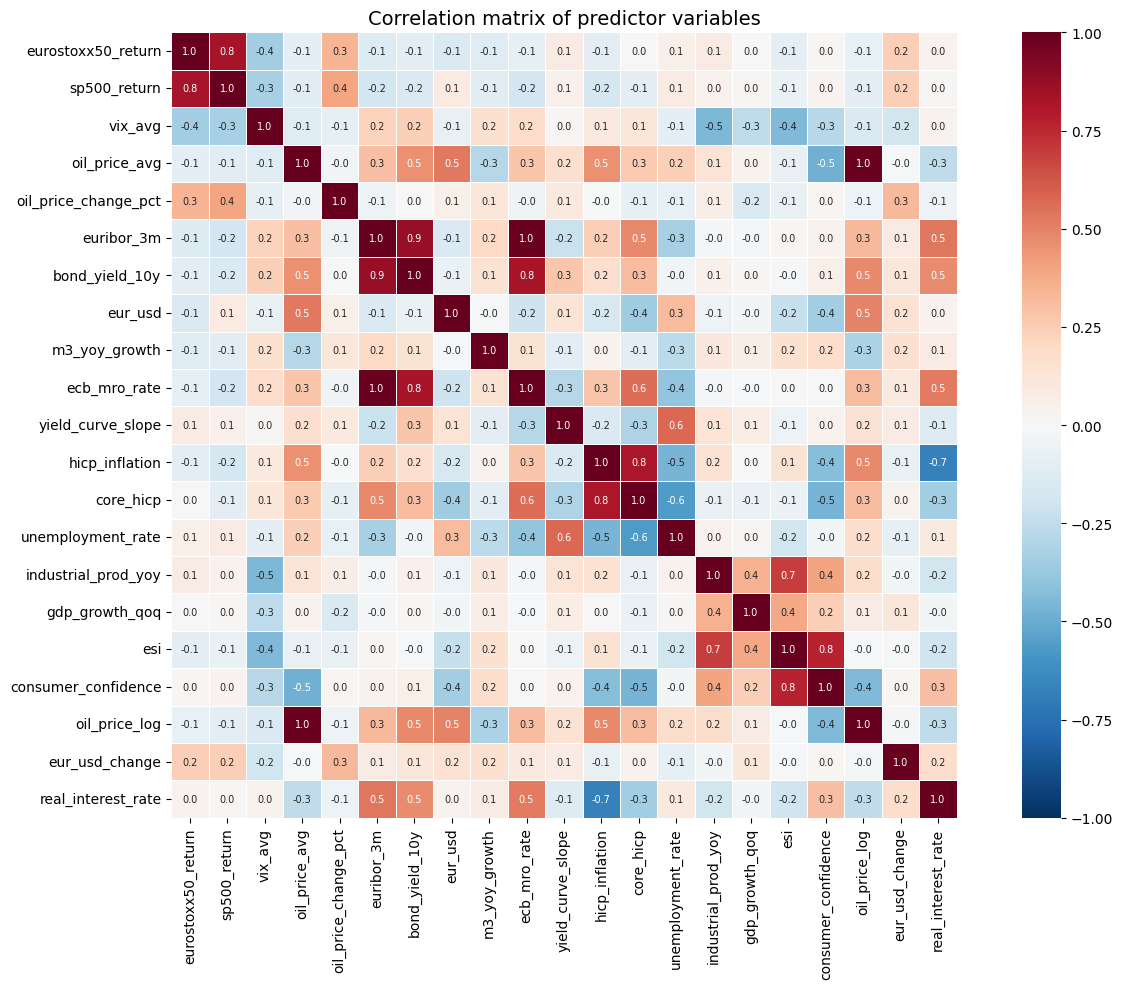


Key observations:
- Variables from the same category (e.g. interest rates) tend to be highly correlated
- Stock returns have low correlation with macro variables (different information content)
- High correlations between ECB rate and Euribor are expected — they're fine for neural networks
  (unlike linear regression, NNs handle multicollinearity without coefficient instability)


In [18]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(14, 10))

# Only include columns with enough data
valid_cols = [c for c in pred_cols if predictors[c].notna().sum() > 20]
corr_matrix = predictors[valid_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt=".1f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax,
            annot_kws={"size": 7})
ax.set_title("Correlation matrix of predictor variables", fontsize=14)
plt.tight_layout()
plt.show()

print("\nKey observations:")
print("- Variables from the same category (e.g. interest rates) tend to be highly correlated")
print("- Stock returns have low correlation with macro variables (different information content)")
print("- High correlations between ECB rate and Euribor are expected — they're fine for neural networks")
print("  (unlike linear regression, NNs handle multicollinearity without coefficient instability)")


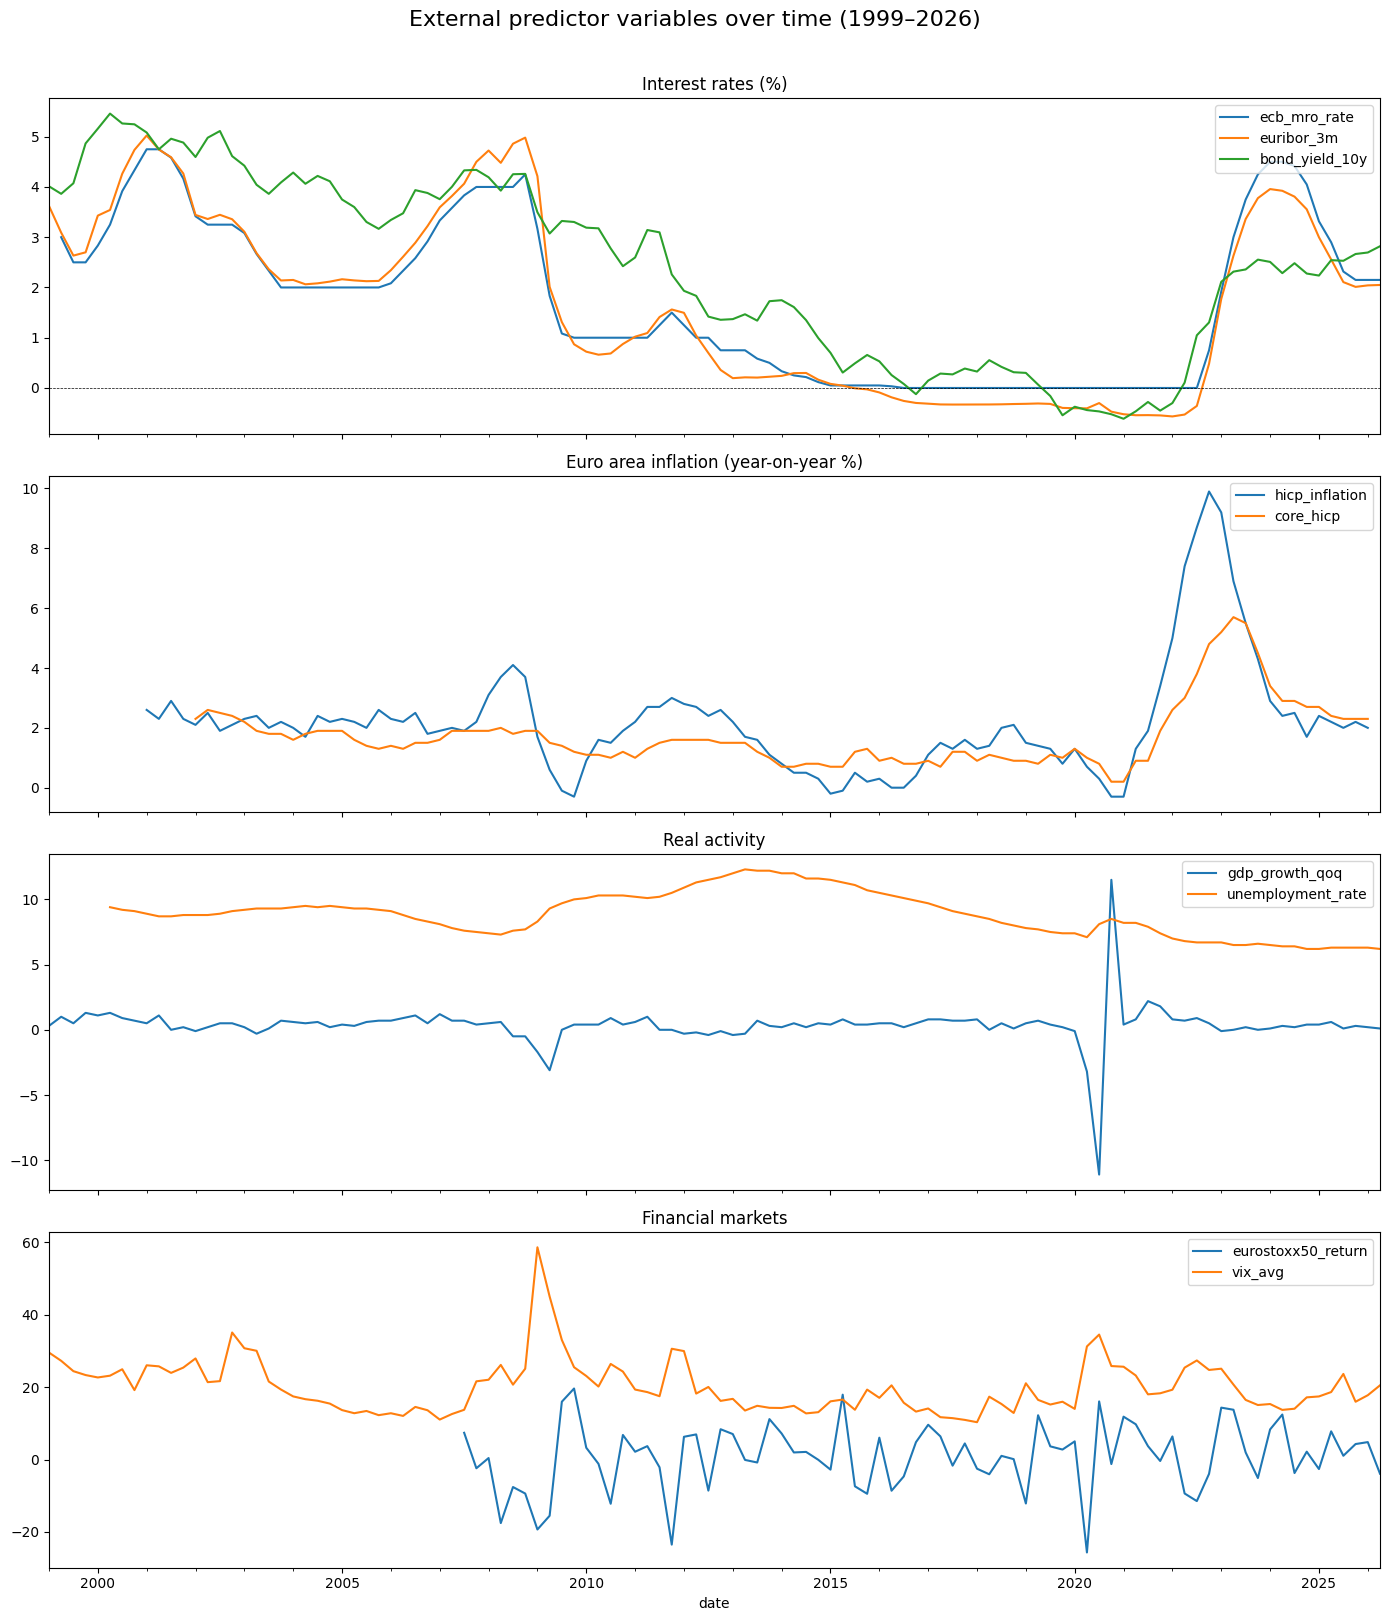

In [19]:
# Time series plot of selected predictors
fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=True)

# Parse survey_round to a plottable date
plot_df = predictors.copy()
plot_df["date"] = pd.to_datetime(
    plot_df["survey_round"].str[:4] + "-" +
    ((plot_df["survey_round"].str[-1].astype(int) - 1) * 3 + 1).astype(str).str.zfill(2) + "-01"
)
plot_df = plot_df.set_index("date")

# Panel 1: Interest rates
rate_cols = [c for c in ["ecb_mro_rate", "euribor_3m", "bond_yield_10y"] if c in plot_df.columns]
if rate_cols:
    plot_df[rate_cols].plot(ax=axes[0], linewidth=1.5)
    axes[0].set_title("Interest rates (%)")
    axes[0].legend(loc="upper right")
    axes[0].axhline(y=0, color="black", linewidth=0.5, linestyle="--")

# Panel 2: Inflation
infl_cols = [c for c in ["hicp_inflation", "core_hicp"] if c in plot_df.columns]
if infl_cols:
    plot_df[infl_cols].plot(ax=axes[1], linewidth=1.5)
    axes[1].set_title("Euro area inflation (year-on-year %)")
    axes[1].legend(loc="upper right")

# Panel 3: Real activity
act_cols = [c for c in ["gdp_growth_qoq", "unemployment_rate"] if c in plot_df.columns]
if act_cols:
    plot_df[act_cols].plot(ax=axes[2], linewidth=1.5)
    axes[2].set_title("Real activity")
    axes[2].legend(loc="upper right")

# Panel 4: Financial markets
fin_cols = [c for c in ["eurostoxx50_return", "vix_avg"] if c in plot_df.columns]
if fin_cols:
    plot_df[fin_cols].plot(ax=axes[3], linewidth=1.5)
    axes[3].set_title("Financial markets")
    axes[3].legend(loc="upper right")

plt.suptitle("External predictor variables over time (1999–2026)", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()


---
## 11 — Save the predictor dataset

We save the predictor dataset as a CSV file. Each row is one survey round,
and the columns are the predictor variables.

In the next notebook (Step 3), we will merge this predictor dataset with
the SPF forecast data from Step 1, compute forecast errors, and train
the neural network.


In [20]:
# Save the predictor dataset
output_path = os.path.join("Data", "external_predictors.csv")
predictors.to_csv(output_path, index=False)

print(f"Saved predictor dataset to: {output_path}")
print(f"  Rows (survey rounds): {len(predictors)}")
print(f"  Columns: {len(predictors.columns)}")
print()

# Final schema
schema = []
for col in predictors.columns:
    dtype = str(predictors[col].dtype)
    n_valid = predictors[col].notna().sum()
    example = predictors[col].dropna().iloc[0] if predictors[col].notna().any() else None
    schema.append({"column": col, "dtype": dtype, "non_null": n_valid, "example": example})

pd.DataFrame(schema)


Saved predictor dataset to: Data/external_predictors.csv
  Rows (survey rounds): 110
  Columns: 22



,column,dtype,non_null,example
0,survey_round,str,110,1999Q1
1,eurostoxx50_return,float64,76,7.384311
2,sp500_return,float64,110,20.867048
3,vix_avg,float64,110,29.537188
4,oil_price_avg,float64,75,74.029773
5,oil_price_change_pct,float64,74,18.542378
6,euribor_3m,float64,110,3.623333
7,bond_yield_10y,float64,110,4.013333
8,eur_usd,float64,109,1.12328
9,m3_yoy_growth,float64,110,4.994669


---
## Summary

We built an external predictor dataset with ~20 macroeconomic and financial
variables from four free data sources:

**What we did:**

1. **Yahoo Finance** — Downloaded daily stock market data (Euro Stoxx 50,
   S&P 500, VIX, Brent crude oil) and converted to quarterly features
   (returns, averages).

2. **ECB SDW** — Downloaded monetary policy data (ECB MRO rate from daily
   tender-regime series, Euribor, 10-year bond yield, EUR/USD exchange rate,
   M3 annual money growth)
   and converted to quarterly averages. Computed the yield curve slope.

3. **Eurostat** — Downloaded euro area macro data (HICP inflation, core
   HICP, GDP growth, unemployment, industrial production) and sentiment
   indicators (ESI, consumer confidence).

4. **FRED** *(optional)* — Downloaded US macro data (CPI inflation,
   Fed Funds rate) for capturing global factors.

5. **Derived features** — Computed log oil price, EUR/USD change, and
   real interest rate from existing variables.

6. **Information timing** — Applied a 1-quarter lag to all variables to
   ensure we only use data that was available when forecasters made their
   predictions. This prevents look-ahead bias.

**What we have now:**

A clean CSV file (`Data/external_predictors.csv`) with one row per survey
round (1999Q1–2026Q2) and ~20 predictor columns. This will be merged with
the SPF forecast data from Step 1 in the next notebook.
